In [6]:
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/synthetic_transactions_with_covariates.csv')

print(f"\nShape: {df.shape}")
print(f"Unique claims: {df['claim_no'].nunique()}")
print(f"Total transactions: {len(df)}")


Shape: (17684, 15)
Unique claims: 3624
Total transactions: 17684


In [7]:
'''
Data Dictionary - SynthETIC Transaction Dataset

claim_no            → Claim number, which uniquely characterises each claim.
pmt_no              → Payment number, identification number of partial payments 
                    in respect of a particular claim_no.
occurrence_period   → Integer; period of occurrence of the claim.
occurrence_time     → Double; time of occurrence of the claim (decimal within period).
claim_size          → Size of the claim (in constant dollar values).
notidel             → Notification delay of the claim, i.e. time from occurrence 
                    to notification.
setldel             → Settlement delay of the claim, i.e. time from notification 
                    to settlement.
payment_time        → Double; time of payment (on a continuous time scale).
payment_period      → Integer; time of payment (in calendar period). 
                    THIS IS YOUR TIME AXIS.
payment_size        → Size of the payment in constant dollar terms.
payment_inflated    → Actual size of the payment (i.e. with inflation).
payment_delay       → Inter-partial delay associated with the payment.
'''
df.head(10)

,claim_no,pmt_no,occurrence_period,occurrence_time,claim_size,notidel,setldel,payment_time,payment_period,payment_size,payment_inflated,payment_delay,legal_representation,injury_severity,age_of_claimant
0,1,1,1,0.62,"294,223.32",0.93,16.29,8.48,9,"20,536.32","21,416.34",6.92,Y,1,50-65
1,1,2,1,0.62,"294,223.32",0.93,16.29,10.29,11,"17,542.25","18,459.30",1.82,Y,1,50-65
2,1,3,1,0.62,"294,223.32",0.93,16.29,16.89,17,"236,377.45","256,990.79",6.60,Y,1,50-65
3,1,4,1,0.62,"294,223.32",0.93,16.29,17.84,18,"19,767.30","21,592.92",0.95,Y,1,50-65
4,2,1,1,0.12,"236,808.92",0.59,28.06,4.84,5,"7,270.62","7,446.81",4.12,Y,2,0-15
5,2,2,1,0.12,"236,808.92",0.59,28.06,10.34,11,"7,586.43","7,985.04",5.51,Y,2,0-15
6,2,3,1,0.12,"236,808.92",0.59,28.06,12.91,13,"8,229.82","8,772.93",2.56,Y,2,0-15
7,2,4,1,0.12,"236,808.92",0.59,28.06,16.54,17,"5,016.46","5,444.52",3.63,Y,2,0-15
8,2,5,1,0.12,"236,808.92",0.59,28.06,20.88,21,"5,839.07","6,474.81",4.34,Y,2,0-15
9,2,6,1,0.12,"236,808.92",0.59,28.06,24.84,25,"6,824.11","7,716.97",3.96,Y,2,0-15


## Data quality checks

This is SynthETIC-simulated data, so we don't expect real-world messiness — but verify rather than assume: nulls, duplicates, negative values.

In [8]:
print('--- nulls ---')
print(df.isnull().sum().sum(), 'total null cells')

print('\n--- duplicates ---')
print('full-row dupes:', df.duplicated().sum())
print('(claim_no, pmt_no) dupes:', df.duplicated(subset=['claim_no', 'pmt_no']).sum())

print('\n--- negative values ---')
for c in ['claim_size', 'payment_size', 'payment_inflated', 'payment_delay', 'notidel', 'setldel']:
    n = (df[c] < 0).sum()
    if n:
        print(f'  {c}: {n} negative values')
print('  none found' if not any((df[c] < 0).sum() for c in ['claim_size','payment_size','payment_inflated','payment_delay','notidel','setldel']) else '')

--- nulls ---
0 total null cells

--- duplicates ---
full-row dupes: 0
(claim_no, pmt_no) dupes: 0

--- negative values ---
  none found


## Exploratory Data Analysis
Here's the menu of everything else worth looking at, grouped so it's easy to scan and pick from:

A. Single-column distributions (what does one thing look like on its own)
1. claim_size distribution (raw + log-scale) — heavy right skew we already know is there
2. Payments-per-claim distribution (how many payments does a typical claim get)
3. Claim duration distribution (occurrence → last payment)
4. legal_representation counts (the third covariate, heavily skewed toward Y)
5. payment_size vs payment_inflated — how much inflation adds, distribution of the ratio

B. Covariates vs. claim_size/severity (does the covariate actually matter)
6. claim_size by injury_severity (box plot, not just means — see the spread, not just averages)
7. claim_size by age_of_claimant
8. claim_size by legal_representation
9. Combinations — e.g. injury_severity × legal_representation heatmap (do lawyers show up more on severe claims?)

C. Covariates vs. development pattern (does the covariate affect timing, not just size — this is the one that matters most for clustering later)
10. notidel (reporting speed) by injury_severity/age_of_claimant/legal_representation
11. setldel (time to close) by the same three
12. Payments-per-claim by injury_severity (do severe claims get more, smaller payments, or fewer, bigger ones?)

D. Time axis / portfolio shape
13. Claims per occurrence_period (already partly seen — is volume steady over the 10 years?)
14. Transaction volume per payment_period (where the data thins out — relevant for picking the evaluation date later)
15. injury_severity/age_of_claimant mix over occurrence periods (is the portfolio's severity mix drifting over the 10 years, or stable?)

E. Sanity/consistency (already trimmed down, but here if you want any back)
16. claim_size reconciliation to sum(payment_size)
17. payment_period vs ceil(payment_time) check

Take a look and let me know which ones (or which letter-group) to do next.

Looking into single column distributions
---------------------------------------
claim size distribution


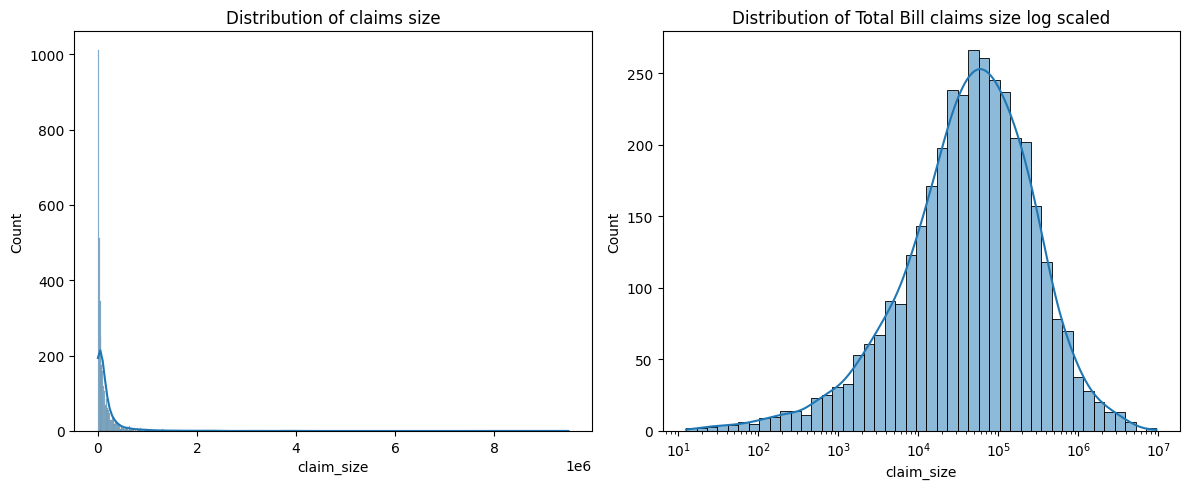

payments per claim distribution


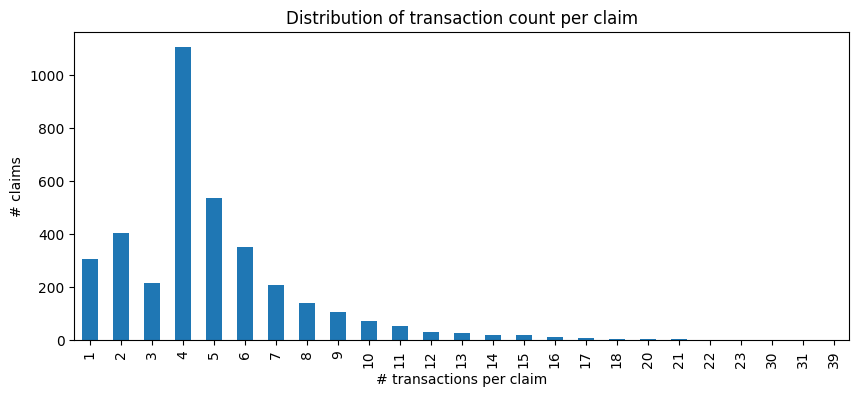

legal representation count
legal_representation
Y    3540
N      84
Name: count, dtype: int64


In [9]:
print("Looking into single column distributions")
print("---------------------------------------")

print("claim size distribution")
claims_unique = df.drop_duplicates('claim_no')
# print(claims_unique['claim_size'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data = claims_unique, x= 'claim_size', ax= axes[0], kde=True) 
axes[0].set_title("Distribution of claims size")

sns.histplot(data = claims_unique, x = 'claim_size', ax = axes[1], kde=True, log_scale = True) 
axes[1].set_title("Distribution of Total Bill claims size log scaled")
plt.tight_layout() 
plt.show()

print('payments per claim distribution')
payments_per_claim = df.groupby('claim_no').size()
freq_table = payments_per_claim.value_counts().sort_index()
freq_table.plot(kind='bar', figsize=(10, 4))
plt.xlabel('# transactions per claim')
plt.ylabel('# claims')
plt.title('Distribution of transaction count per claim')
plt.show()

print('legal representation count')
legal_count = claims_unique['legal_representation'].value_counts()
print(legal_count)

Looking into Covariates vs claim size/severity


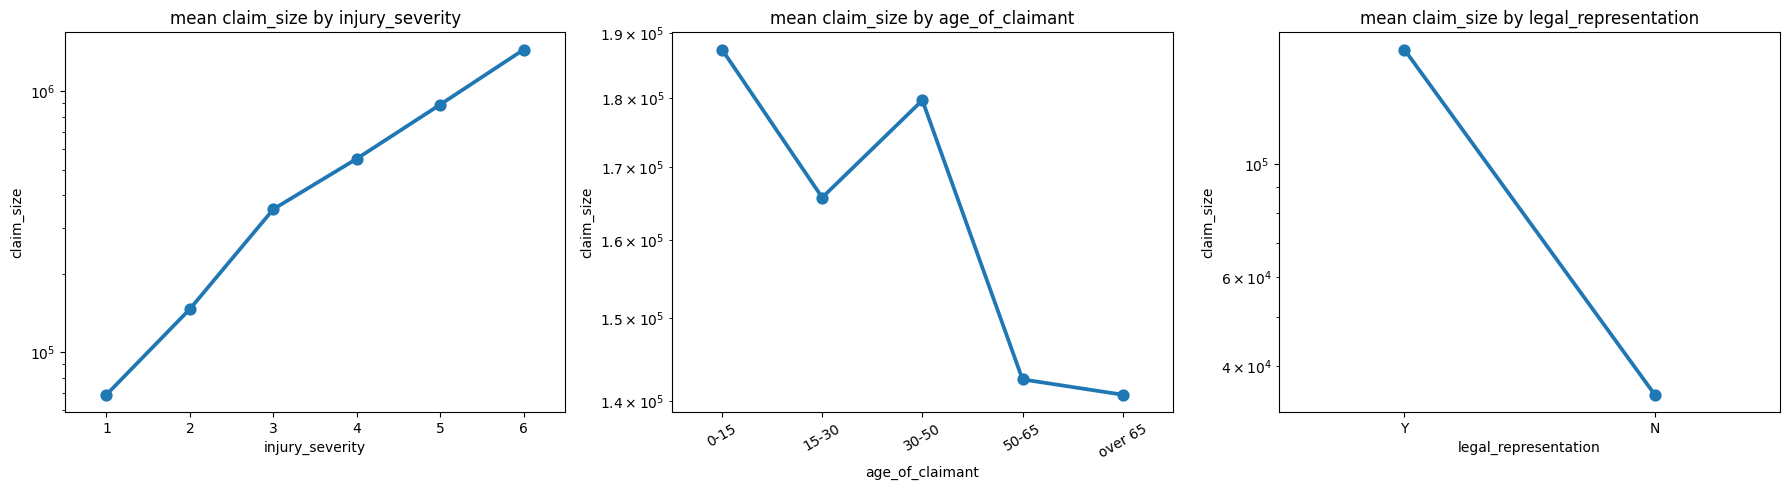

In [10]:
print("Looking into Covariates vs claim size/severity")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.pointplot(data=claims_unique, x='injury_severity', y='claim_size', errorbar=None, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('mean claim_size by injury_severity')

age_order = ['0-15', '15-30', '30-50', '50-65', 'over 65']
sns.pointplot(data=claims_unique, x='age_of_claimant', y='claim_size', order=age_order, errorbar=None, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('mean claim_size by age_of_claimant')
axes[1].tick_params(axis='x', rotation=30)

sns.pointplot(data=claims_unique, x='legal_representation', y='claim_size', errorbar=None, ax=axes[2])
axes[2].set_yscale('log')
axes[2].set_title('mean claim_size by legal_representation')

plt.tight_layout()
plt.show()

C. Covariates vs. development pattern (does the covariate affect timing, not just size — this is the one that matters most for clustering later)
10. notidel (reporting speed) by injury_severity/age_of_claimant/legal_representation
11. setldel (time to close) by the same three
12. Payments-per-claim by injury_severity (do severe claims get more, smaller payments, or fewer, bigger ones?)

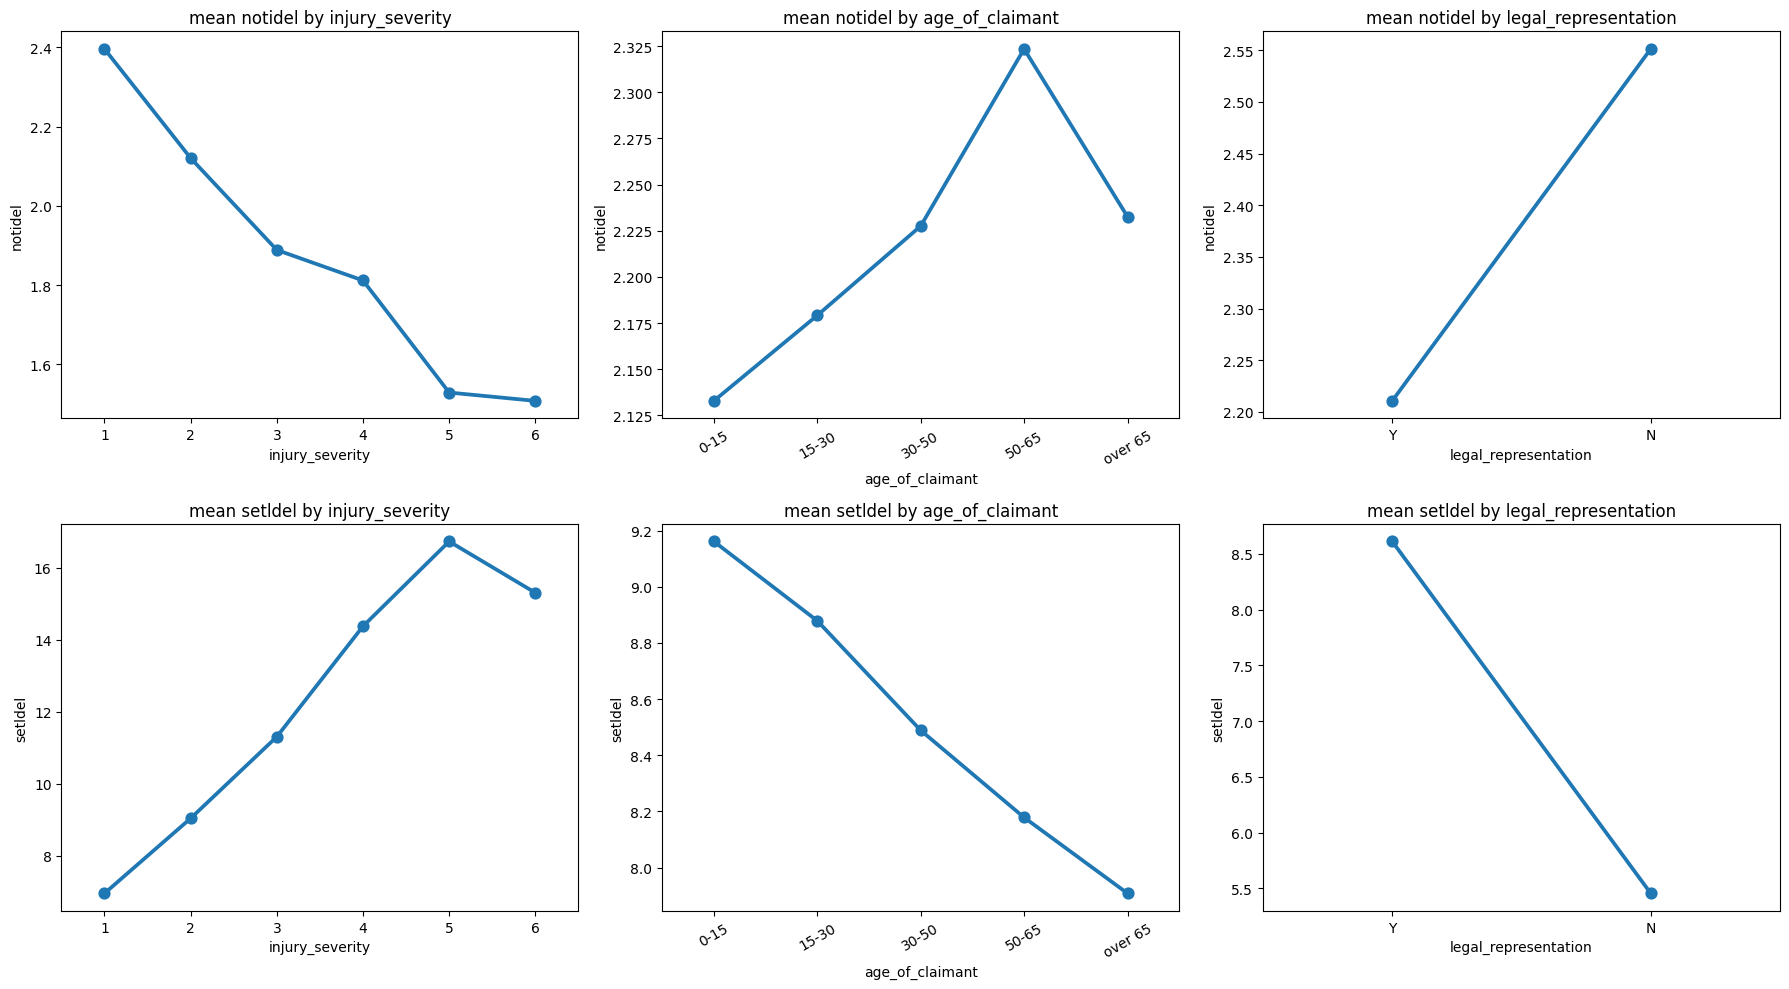

In [11]:
# analyze whether the covariates change the shape/speed of a claim's life, not just the claim size. This is the one that validates whether clustering have something real to work with

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
age_order = ['0-15', '15-30', '30-50', '50-65', 'over 65']

# --- row 1: notidel ---
sns.pointplot(data=claims_unique, x='injury_severity', y='notidel', errorbar=None, ax=axes[0, 0])
axes[0, 0].set_title('mean notidel by injury_severity')

sns.pointplot(data=claims_unique, x='age_of_claimant', y='notidel', order=age_order, errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title('mean notidel by age_of_claimant')
axes[0, 1].tick_params(axis='x', rotation=30)

sns.pointplot(data=claims_unique, x='legal_representation', y='notidel', errorbar=None, ax=axes[0, 2])
axes[0, 2].set_title('mean notidel by legal_representation')

# --- row 2: setldel ---
sns.pointplot(data=claims_unique, x='injury_severity', y='setldel', errorbar=None, ax=axes[1, 0])
axes[1, 0].set_title('mean setldel by injury_severity')

sns.pointplot(data=claims_unique, x='age_of_claimant', y='setldel', order=age_order, errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title('mean setldel by age_of_claimant')
axes[1, 1].tick_params(axis='x', rotation=30)

sns.pointplot(data=claims_unique, x='legal_representation', y='setldel', errorbar=None, ax=axes[1, 2])
axes[1, 2].set_title('mean setldel by legal_representation')

plt.tight_layout()
plt.show()

Transaction volume by payment_period — where does the data thin out?


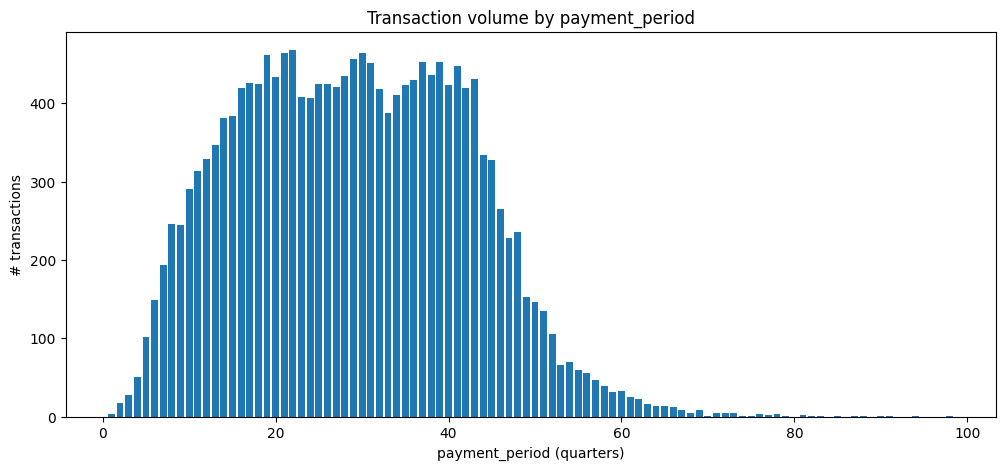

count    89.00
mean    198.70
std     188.65
min       1.00
25%       8.00
50%     146.00
75%     419.00
max     468.00
dtype: float64

last period with data: 98
periods with fewer than 10 transactions:
payment_period
1     3
67    8
68    4
69    8
70    1
71    5
72    4
73    5
74    1
75    1
76    3
77    2
78    3
79    1
81    2
82    1
83    1
85    1
87    1
88    1
90    1
91    1
94    1
98    1
dtype: int64


In [12]:
print("Transaction volume by payment_period — where does the data thin out?")

n_transactions_per_period = df.groupby('payment_period').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(n_transactions_per_period.index, n_transactions_per_period.values)
ax.set_xlabel('payment_period (quarters)')
ax.set_ylabel('# transactions')
ax.set_title('Transaction volume by payment_period')
plt.show()

print(n_transactions_per_period.describe())
print()
print('last period with data:', n_transactions_per_period.index.max())
print('periods with fewer than 10 transactions:')
print(n_transactions_per_period[n_transactions_per_period < 10])

In [13]:
cutoff = 40

history = df[df['payment_period'] <= cutoff]
future = df[df['payment_period'] > cutoff]

print(f"History (payment_period <= {cutoff}): {len(history)} transactions ({len(history)/len(df)*100:.1f}%)")

History (payment_period <= 40): 13896 transactions (78.6%)


We picked payment_period = 40 as a pretend "today." Everything that happened at or before period 40 is what we're allowed to use — that's the history (78.8% of all transactions). Everything after period 40 — periods 41 through 99 — we're deliberately setting aside and not looking at while building anything. That's the holdout (21.2% of transactions).

Why we're holding it out: because this is simulated data, that "future" portion already exists in the file — we could look at it right now if we wanted to. But if we let our prediction model see it, we'd never be able to tell whether the model is actually good at forecasting, or just copying answers it was allowed to peek at. So we cover it up on purpose, build the whole pipeline (snapshot triangle → prediction models → clustering → reserves) using only the history side, and treat the holdout side as if it doesn't exist yet.

What it's for, later: once predictions are made using only the history, we uncover the holdout side and compare — did the model's prediction for "what happens to this claim next" actually match what really happened in periods 41–99? That comparison is how we'll know if the whole methodology (not just this one dataset) actually works, rather than just assuming it does.

Why 21.2% specifically, not some other number: we checked several cutoffs (30, 40, 50, 60, 70, 80) and found that anything past 50 leaves less than 5% of the data held out — too thin to reliably check predictions, especially for claims we're trying to predict far into their future (12–24 quarters out). 40 was also the earliest cutoff that's even valid, since some claims don't occur until period 40 itself. 21.2% held out was the best balance of "enough history to build good features" and "enough future left over to genuinely grade ourselves."

In [14]:
df.head(10)

,claim_no,pmt_no,occurrence_period,occurrence_time,claim_size,notidel,setldel,payment_time,payment_period,payment_size,payment_inflated,payment_delay,legal_representation,injury_severity,age_of_claimant
0,1,1,1,0.62,"294,223.32",0.93,16.29,8.48,9,"20,536.32","21,416.34",6.92,Y,1,50-65
1,1,2,1,0.62,"294,223.32",0.93,16.29,10.29,11,"17,542.25","18,459.30",1.82,Y,1,50-65
2,1,3,1,0.62,"294,223.32",0.93,16.29,16.89,17,"236,377.45","256,990.79",6.60,Y,1,50-65
3,1,4,1,0.62,"294,223.32",0.93,16.29,17.84,18,"19,767.30","21,592.92",0.95,Y,1,50-65
4,2,1,1,0.12,"236,808.92",0.59,28.06,4.84,5,"7,270.62","7,446.81",4.12,Y,2,0-15
5,2,2,1,0.12,"236,808.92",0.59,28.06,10.34,11,"7,586.43","7,985.04",5.51,Y,2,0-15
6,2,3,1,0.12,"236,808.92",0.59,28.06,12.91,13,"8,229.82","8,772.93",2.56,Y,2,0-15
7,2,4,1,0.12,"236,808.92",0.59,28.06,16.54,17,"5,016.46","5,444.52",3.63,Y,2,0-15
8,2,5,1,0.12,"236,808.92",0.59,28.06,20.88,21,"5,839.07","6,474.81",4.34,Y,2,0-15
9,2,6,1,0.12,"236,808.92",0.59,28.06,24.84,25,"6,824.11","7,716.97",3.96,Y,2,0-15
